# 《LangChain RAG项目实践实验》

## 一、实验目的
1. 理解 RAG 技术在实际项目中的应用架构与完整流程
2. 掌握文档收集、文档处理、文档向量化的完整数据准备流程
3. 掌握使用 LangChain 构建 RAG 检索增强生成系统的方法
4. 掌握 LCEL 链式调用、记忆组件、提示词模板的综合运用
5. 完成基于 RAG 的智能客服问答系统项目实践

## 二、实验环境
- 系统：Windows 10
- Python版本：3.10
- 虚拟环境：Miniconda
- 开发工具：VS Code / Jupyter Notebook
- 依赖库：langchain、langchain-core、langchain-community、langchain-redis、langchain-deepseek、python-dotenv、beautifulsoup4、playwright
- 模型：DeepSeek（deepseek-chat）
- 存储：Redis


## 三、实验原理

### 3.1 项目介绍

随着美团业务的不断扩展，客服人员需要应对海量的用户咨询，包括订单问题、退款流程、配送异常、优惠政策等。传统的知识库客服系统依赖规则匹配，回答僵硬，难以及时覆盖最新的业务规则。

为提升客户体验和客服效率，本项目基于 RAG（Retrieval-Augmented Generation，检索增强生成）技术构建智能客服问答系统，将美团内部文档知识与大语言模型结合，实现更智能、更准确的自动化答复。

### 项目功能

针对智能客服系统本身，我们将采用 RAG + LLM 来完成这一需求。结合前面所学的知识，这个智能客服系统应该具备以下功能：

- 支持历史记忆功能，并且能够实现历史记忆持久化。
- 使用 LCEL 表达式来构建链。
- 支持 RAG 检索功能，使大语言模型能够根据知识库文档内容进行作答。
- 编写完善的提示词模板，内容包括历史对话信息、RAG 检索的上下文信息、用户提问，以及 AI 作为客服的系统提示词。

### 3.2 系统架构

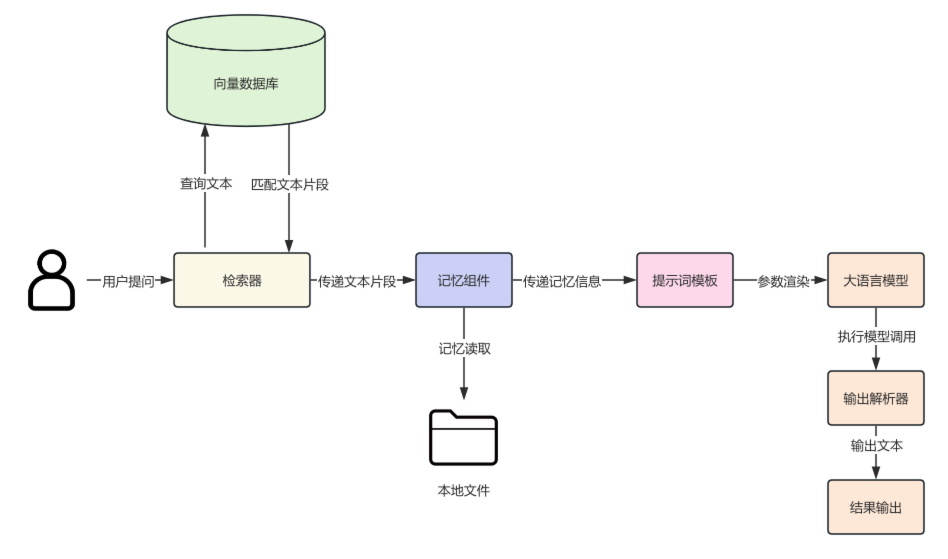

### 3.3 RAG准备阶段

在 RAG 准备阶段，我们需要进行文档收集、文档处理、文档数据向量化操作以及文档相似性检索测试。

### 3.4 RAG系统实现

接下来，开始实现智能客服系统，主要包含以下 8 个步骤：

（1）创建提示词模板：模板包括系统消息、消息占位符、人类消息。

（2）构建模型：使用 deepseek-chat 模型。

（3）创建输出解析器：创建一个字符串输出解析器，用于结果输出。

（4）构建检索器：连接向量数据库，创建检索器。

（5）创建记忆组件：构建记忆组件，实现历史对话持久化。

（6）构建链：构建 LCEL 链。

（7）调用链：使用 stream() 方法实现流式输出。

（8）记忆保存：将对话记忆进行持久化。

## 四、实验内容

### 4.1 环境准备

安装依赖库。

In [ ]:
# 安装浏览器插件库
pip install playwright chromium
playwright install

### 4.2 文档收集

收集美团客服相关知识文档，以美团外卖常见问题为例，文档地址：https://waimai.meituan.com/help/faq，通过 playwright 工具爬虫获取页面数据并写入本地文件中。

In [ ]:
from playwright.sync_api import sync_playwright


def collect_faq(url):
    """
    收集指定URL页面中的FAQ内容
    """
    with sync_playwright() as p:
        browser = p.chromium.launch(
            headless=False,
            args=['--lang=zh-CN']
        )
        page = browser.new_page(
            locale='zh-CN',
            user_agent=(
                "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                "AppleWebKit/537.36 (KHTML, like Gecko) "
                "Chrome/139.0.0.0 Safari/537.36 Edg/139.0.0.0"
            ),
            extra_http_headers={"Accept-Language": "zh-CN,zh;q=0.9"}
        )
        page.goto(url, timeout=30_000)
        page.wait_for_load_state("networkidle")
        raw_text = page.locator("#faq-list").first.inner_html()
        browser.close()
        return raw_text


def save_faq(cleaned_text: str, output_file: str):
    with open(output_file, "w", encoding="utf-8") as f:
        f.write(cleaned_text)
    print(f"FAQ 已保存到 {output_file}")


if __name__ == "__main__":
    cleaned_text = collect_faq(url="https://waimai.meituan.com/help/faq")
    output_file = "faq.html"
    save_faq(cleaned_text, output_file)

### 4.3 文档处理

对收集到的文档进行统一处理，内容包括：

- 文本清洗（去除 HTML 标签、无关字符）
- 分段切分（按规则或语义将文档拆分成小片段，便于检索）
- 元数据标注（来源、时间、业务类别等）

In [ ]:
import json
from bs4 import BeautifulSoup
from langchain.schema import Document


def parse_faq_html(file_path):
    """
    解析FAQ HTML文件，提取问题和答案信息并封装为Document对象列表。
    """
    docs = []
    with open(file_path, "r", encoding="utf-8") as f:
        soup = BeautifulSoup(f, "html.parser")

    current_category = None

    for ul in soup.find_all("ul"):
        for li in ul.find_all("li", recursive=False):
            h1 = li.find("h1")
            if h1:
                current_category = h1.get_text(strip=True)
                continue

            dl = li.find("dl")
            if dl:
                question_raw = dl.find("dt").get_text(strip=True)
                question = question_raw.lstrip("Q：").strip()
                answer = dl.find("dd").get_text(strip=True)

                docs.append(
                    Document(
                        page_content="",
                        metadata={
                            "source": file_path,
                            "category": current_category,
                            "question": question,
                            "answer": answer
                        }
                    )
                )
    return docs


def save_docs_to_json(docs, output_file):
    data = [
        {
            "question": doc.metadata["question"],
            "answer": doc.metadata["answer"],
            "category": doc.metadata["category"],
            "source": doc.metadata["source"]
        }
        for doc in docs
    ]
    with open(output_file, "w", encoding="utf-8") as f:
        json.dump(data, f, ensure_ascii=False, indent=2)
    print(f"FAQ 已保存到 {output_file}")


if __name__ == "__main__":
    faq_docs = parse_faq_html("faq.html")
    for d in faq_docs:
        print(d.metadata)
    save_docs_to_json(faq_docs, "faq.json")

### 4.4 文档数据向量化

将 FAQ 数据格式化成 json 数据后，接下来就要转成向量数据并存储到向量数据库中，此处以 redis 为例。

In [ ]:
import json
from langchain_redis import RedisConfig, RedisVectorStore
from langchain_community.embeddings import DashScopeEmbeddings
import os
from dotenv import load_dotenv

load_dotenv(override=True)
qwen_api_key = os.getenv("QWEN_API_KEY")


def insert_faq(texts, meta_data):
    embedding = DashScopeEmbeddings(
        model="text-embedding-v2",
        dashscope_api_key=qwen_api_key
    )
    config = RedisConfig(index_name="faq", redis_url="redis://localhost:6379")
    vector_store = RedisVectorStore(embedding, config=config)
    vector_store.add_texts(texts=texts, metadatas=meta_data)


def insert_from_file(file_path):
    with open(file_path, "r", encoding="utf-8") as f:
        docs = json.load(f)
    texts = []
    meta_data = []
    for doc in docs:
        texts.append(doc["question"])
        meta_data.append({
            "answer": doc["answer"],
            "category": doc["category"],
            "source": doc["source"]
        })
    insert_faq(texts, meta_data)


if __name__ == "__main__":
    insert_from_file("faq.json")

### 4.5 文档数据相似性检索

文档向量数据写入数据库后，测试验证召回数据准确性。用户提问后，将问题转换为向量，与向量数据库中的文档进行相似性匹配，召回与问题最相关的文档片段。

In [ ]:
def search_question(question):
    embedding = DashScopeEmbeddings(
        model="text-embedding-v2",
        dashscope_api_key=qwen_api_key
    )
    config = RedisConfig(index_name="faq", redis_url="redis://localhost:6379")
    vector_store = RedisVectorStore(embedding, config=config)

    retriever = vector_store.as_retriever()
    documents = retriever.invoke(question)

    for document in documents:
        print(document.page_content)
        print(document.metadata)
        print("=================================")


if __name__ == "__main__":
    search_question("在线支付取消订单后钱怎么返还给我呢")

### 4.6 构建提示词

把用户问题 + 检索召回的上下文拼接成一个高质量的 Prompt 送给大模型。

In [ ]:
from langchain_core.prompts import PromptTemplate


def build_prompt(question: str):
    embedding = DashScopeEmbeddings(
        model="text-embedding-v2",
        dashscope_api_key=qwen_api_key
    )
    config = RedisConfig(index_name="faq", redis_url="redis://localhost:6379")
    vector_store = RedisVectorStore(embedding, config=config)

    retriever = vector_store.as_retriever(search_kwargs={"k": 2})
    documents = retriever.invoke(question)

    context = "\n\n".join(
        f"【文档片段{i + 1}】\nQ: {doc.page_content}\nA: {doc.metadata.get('answer', '')}"
        for i, doc in enumerate(documents)
    )

    template = """
    你是一个外卖公司的智能客服，接下来你将扮演一个专业客服的角色，
    对用户提出来的商品问题进行回答，一定要礼貌热情，如果用户提问与客服和商品无关的问题，
    礼貌委婉的表示拒绝或无法回答，只回答外卖服务相关的问题。

    用户问题：
    {question}

    可用文档片段：
    {context}

    请基于以上信息，生成简洁明了的回答：
    """
    prompt_template = PromptTemplate(
        input_variables=["question", "context"], template=template
    )

    prompt = prompt_template.format(question=question, context=context)
    print("=== 提示词 ===")
    print(prompt)
    print("=================================")
    return prompt


if __name__ == "__main__":
    build_prompt("在线支付取消订单后钱怎么返还给我呢")

### 4.7 RAG系统实现

接下来，开始实现智能客服系统。

In [ ]:
from langchain_core.output_parsers import StrOutputParser
from langchain_deepseek import ChatDeepSeek
from langchain_redis import RedisConfig, RedisVectorStore, RedisChatMessageHistory
from langchain_core.prompts import PromptTemplate
from langchain_core.runnables import RunnableWithMessageHistory
import os


def format_docs(docs):
    return "\n\n".join(
        f"【文档片段{i + 1}】\n"
        f"Q: {doc.page_content}\n"
        f"A: {doc.metadata.get('answer', '')}"
        for i, doc in enumerate(docs)
    )


def extract_question(x):
    if isinstance(x, str):
        return x
    return x[-1].content


def build_chain():
    embedding = DashScopeEmbeddings(
        model="text-embedding-v2",
        dashscope_api_key=qwen_api_key
    )
    config = RedisConfig(index_name="faq", redis_url="redis://localhost:6379")
    vector_store = RedisVectorStore(embedding, config=config)
    retriever = vector_store.as_retriever(search_kwargs={"k": 2})

    template = """
    你是一个外卖公司的智能客服，接下来你将扮演一个专业客服的角色，
    对用户提出来的商品问题进行回答，一定要礼貌热情，如果用户提问与客服和商品无关的问题，
    礼貌委婉的表示拒绝或无法回答，只回答外卖服务相关的问题。

    用户问题：
    {question}

    可用文档片段：
    {context}

    请基于以上信息，生成简洁明了的回答：
    """
    prompt = PromptTemplate.from_template(template)

    llm = ChatDeepSeek(
        model="deepseek-chat",
        temperature=0,
        api_key=os.getenv("DEEPSEEK_API_KEY")
    )
    parser = StrOutputParser()

    chain = (
        {
            "context": extract_question | retriever | format_docs,
            "question": extract_question,
        }
        | prompt
        | llm
        | parser
    )
    return chain


def main():
    chain = build_chain()
    history = RedisChatMessageHistory(session_id='rag', redis_url='redis://localhost:6379/0')

    runnable = RunnableWithMessageHistory(
        chain,
        get_session_history=lambda: history
    )

    print(">>> 欢迎使用外卖智能客服系统，输入 quit/exit 退出 <<<")
    while True:
        try:
            user = input("\n您：").strip()
        except (KeyboardInterrupt, EOFError):
            print("\nbye~")
            break
        if user.lower() in {"quit", "exit", "q"}:
            print("客服：祝您生活愉快，再见！")
            break
        answer = runnable.invoke(user)
        print("客服：", answer)


if __name__ == "__main__":
    main()

## 五、实验总结

1. 理解了 RAG 技术在实际项目中的应用架构，掌握了从文档收集到智能问答的完整流程
2. 通过 playwright 爬虫和 BeautifulSoup 解析，掌握了文档收集和文档处理的数据准备方法
3. 使用 RedisVectorStore 实现了文档数据的向量化存储和相似性检索
4. 通过 PromptTemplate 构建了包含上下文信息的提示词模板，理解了 RAG 增强生成的核心机制
5. 综合运用 LCEL 链式调用、RunnableWithMessageHistory 记忆组件、StrOutputParser 输出解析器，完成了智能客服系统的完整实现